In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

#### create and visualise Data

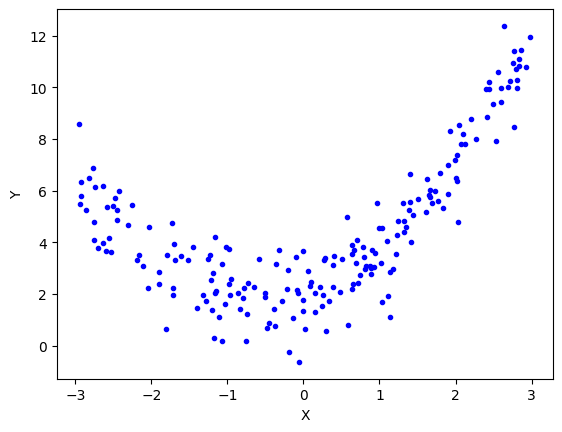

In [7]:
x = 6*np.random.rand(200, 1) -3
y = 0.8*x**2 + 0.9*x +2 + np.random.randn(200,1)
# equation used = y = 0.8x^2 + 0.9x+2
# visualise the data
plt.plot(x,y,'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

#### Split data in the train and test set

In [8]:
x_train ,x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

#### Apply Simple Linear Regression

In [9]:
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(r2_score(y_test, y_pred))

0.16364152043082847


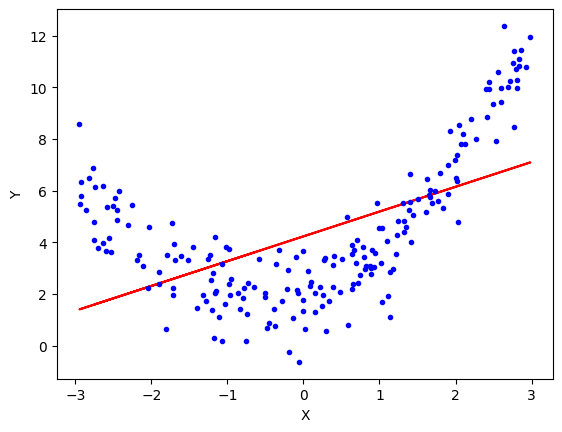

In [10]:
plt.plot(x_train,lr.predict(x_train), color="r")
plt.plot(x, y, "b.")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

#### Apply Polynomial Regression 

In [16]:
# Applying Polynomial regression degree2
poly = PolynomialFeatures(degree=2, include_bias = True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

# include bias parameter
lr = LinearRegression()
lr.fit(x_train_trans, y_train)
y_pred = lr.predict(x_test_trans)
print(r2_score(y_test, y_pred))

0.8723440465268697


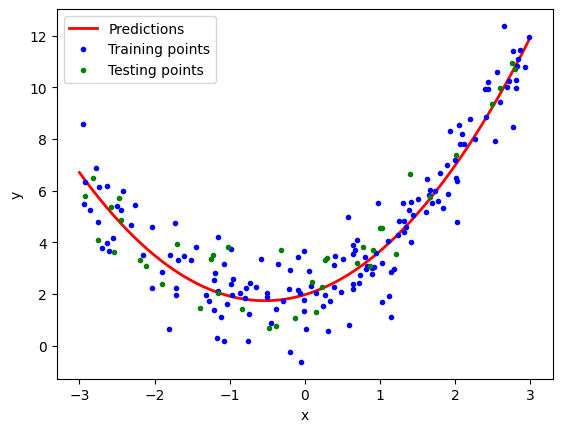

In [18]:
x_new = np.linspace(-3,3,200).reshape(200, 1)
x_new_poly = poly.transform(x_new)
y_new = lr.predict(x_new_poly)
plt.plot(x_new, y_new, "r-",linewidth = 2, label="Predictions")
plt.plot(x_train, y_train, "b.",label= "Training points")
plt.plot(x_test, y_test, "g.",label= "Testing points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()